In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load in movie tower
movie_tower = tf.keras.models.load_model("movie_tower.keras")

# Load in movie data
movies = pd.read_csv("data/movies.csv")
unique_movie_ids = movies['movieId'].unique()

2026-04-04 12:23:09.754334: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-04-04 12:23:09.754411: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-04 12:23:09.754429: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-04 12:23:09.754852: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-04 12:23:09.754893: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:
movie_input = np.array(unique_movie_ids)
movie_embeddings = movie_tower.predict(movie_input)

2026-04-04 12:23:11.302094: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [4]:
tsne = TSNE(n_components=2, perplexity=20, random_state=42)
embeddings_2d = tsne.fit_transform(movie_embeddings)


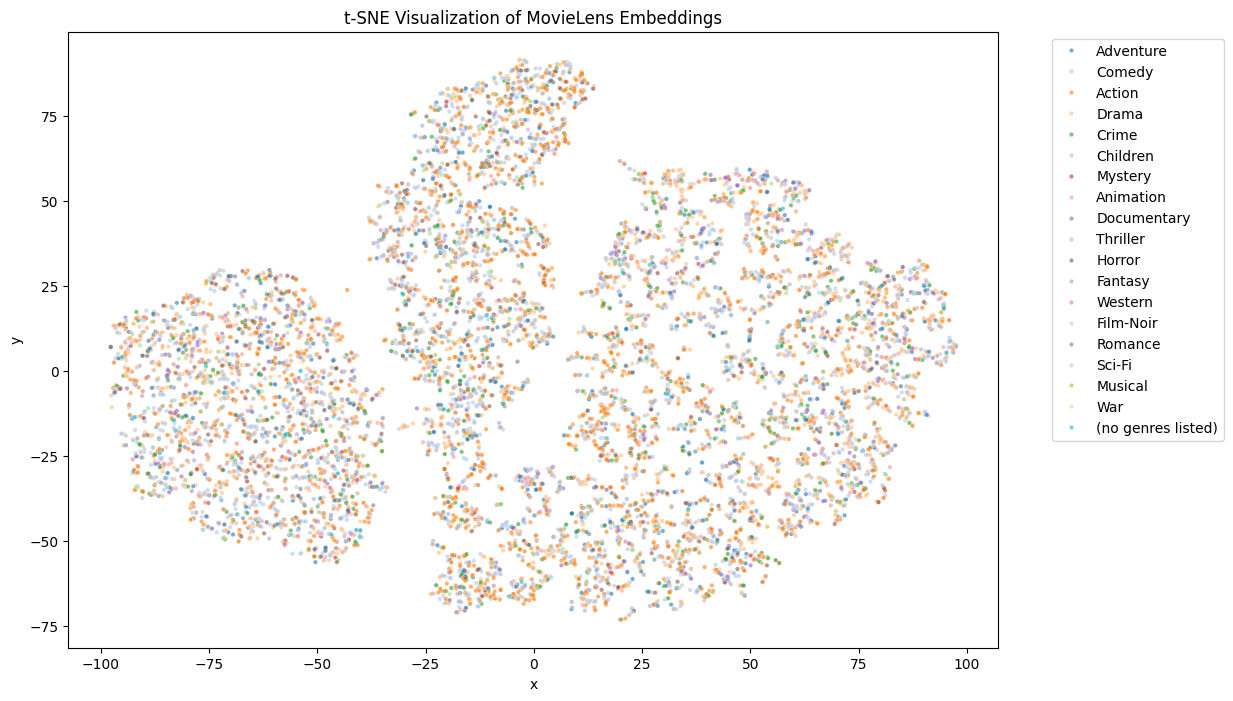

In [5]:
# Create a temporary dataframe for plotting
tsne_df = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'genre': movies['genres'].str.split('|').str[0] # Take the first genre listed
})

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=tsne_df, 
    x='x', y='y', 
    hue='genre', 
    palette='tab20',
 
    alpha=0.6, 
    s=10
)
plt.title('t-SNE Visualization of MovieLens Embeddings')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [6]:
# Make sure movies_df and embeddings_2d have the same number of rows
# (This assumes movies_df is the same one used to generate movie_embeddings)

tsne_df = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'genre': movies['genres'].str.split('|').str[0],
    'title': movies['title'].values  # <--- Add this line!
})

# Now run the plotly code again
import plotly.express as px

fig = px.scatter(
    tsne_df, 
    x='x', 
    y='y', 
    color='genre', 
    hover_data=['title'],
    title="Interactive Movie Clusters"
)
fig.show()

In [19]:
import umap.umap_ as umap 

ratings = pd.read_csv("data/ratings.csv")

umap_model = umap.UMAP(n_components = 2, n_neighbors = 15, min_dist = 0.1, random_state = 42)

embeddings_2d = umap_model.fit_transform(movie_embeddings)

avg_ratings = ratings.groupby('movieId')['rating'].mean().reset_index()
movies_with_ratings = movies.merge(avg_ratings, on='movieId', how='left')

umap_df = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'genre': movies['genres'].str.split('|').str[0],
    'rating': movies['rating'].values
})

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=umap_df,
    x='x', y='y',
    hue='genre',
    palette='tab20',
    alpha=0.6,
    s=10
)

plt.title('UMAP Visualization of MovieLens Embeddings')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


KeyError: 'rating'

In [13]:
umap_df = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'genre': movies['genres'].str.split('|').str[0],
    'title': movies['title'].values
})

fig = px.scatter(
    umap_df,
    x='x',
    y='y',
    color='genre',
    hover_data=['title'],
    title="UMAP Movie Clusters"
)

fig.show()

In [24]:

ratings = pd.read_csv('data/ratings.csv')

embeddings_2d = umap_model.fit_transform(movie_embeddings)

avg_ratings = ratings.groupby('movieId')['rating'].mean().reset_index()

movies_with_ratings = movies.merge(avg_ratings, on='movieId', how='left')

umap_df = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'genre': movies_with_ratings['genres'].str.split('|').str[0],
    'title': movies_with_ratings['title'],
    'rating': movies_with_ratings['rating']
})

fig = px.scatter(
    umap_df,
    x='x',
    y='y',
    color='rating',
    hover_data=['title'],
    title="UMAP Movie Clusters"
)

fig.show()

umap_df.to_csv("data/umap.csv", index=False)